In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
car_data = {
    "Engine_Size": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 1300, 1600,
                    900, 1100, 1400, 1700, 2100, 2300, 2600, 2800, 3000, 3200,
                    850, 1050, 1250, 1550, 1850, 2050, 2250, 2550, 2750, 2950,
                    1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800,
                    900, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500, 2700],

    "Mileage": [22, 20, 18, 16, 14, 13, 12, 10, 19, 15,
                23, 21, 17, 15, 13, 12, 11, 10, 9, 8,
                24, 22, 20, 17, 15, 14, 13, 11, 10, 9,
                21, 19, 18, 16, 14, 13, 12, 11, 10, 9,
                23, 21, 19, 17, 15, 14, 13, 12, 11, 10],

    "Age": [1, 2, 3, 2, 4, 3, 5, 2, 3, 4,
            1, 2, 3, 4, 2, 3, 5, 4, 6, 5,
            1, 2, 3, 2, 4, 3, 5, 2, 4, 3,
            2, 3, 4, 3, 5, 4, 6, 5, 7, 6,
            1, 2, 3, 2, 4, 3, 5, 4, 6, 5],

    "Horsepower": [50, 60, 75, 90, 110, 130, 150, 180, 80, 100,
                   55, 65, 85, 105, 135, 155, 185, 200, 220, 240,
                   52, 62, 78, 95, 115, 135, 155, 175, 195, 215,
                   60, 75, 90, 105, 120, 140, 160, 180, 200, 220,
                   58, 68, 82, 98, 118, 138, 158, 178, 198, 218],

    "Brand_Value": [1,1,1,2,2,2,3,3,1,2,
                    1,1,2,2,2,3,3,3,3,3,
                    1,1,1,2,2,2,3,3,3,3,
                    1,2,2,2,2,3,3,3,3,3,
                    1,1,2,2,2,3,3,3,3,3],

    "Owner_Count": [1,1,2,1,2,1,2,1,2,2,
                    1,2,2,3,1,2,3,2,3,2,
                    1,1,2,1,2,1,2,1,2,1,
                    2,2,3,2,3,2,3,2,3,2,
                    1,2,2,3,2,3,2,3,2,3],

    "Price": [300000, 350000, 400000, 500000, 650000, 750000, 900000, 1200000, 420000, 550000,
              320000, 370000, 480000, 600000, 800000, 950000, 1300000, 1400000, 1600000, 1800000,
              310000, 360000, 420000, 520000, 680000, 780000, 920000, 1150000, 1350000, 1550000,
              340000, 400000, 500000, 600000, 700000, 850000, 1000000, 1150000, 1300000, 1500000,
              330000, 380000, 460000, 560000, 720000, 820000, 960000, 1100000, 1250000, 1450000]
}

In [3]:
df=pd.DataFrame(car_data)

In [4]:
X=df.drop("Price",axis=1)
y=df["Price"]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
scaler=StandardScaler()

In [7]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
model=DecisionTreeRegressor()

In [9]:
param_grid = {
    "criterion": ["squared_error", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": [None, "sqrt", "log2"]
}

In [11]:
cv=GridSearchCV(model,param_grid=param_grid,scoring="neg_mean_squared_error",cv=5)
cv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [13]:
cv.best_params_

{'criterion': 'absolute_error',
 'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

In [14]:
cv.best_score_

np.float64(-2760000000.0)

In [15]:
pre=cv.predict(X_test)

In [16]:
pre

array([ 650000., 1600000.,  370000.,  850000., 1350000., 1150000.,
        950000.,  700000.,  480000., 1600000.])

In [17]:
print(r2_score(y_test,pre))

0.9635605945737079


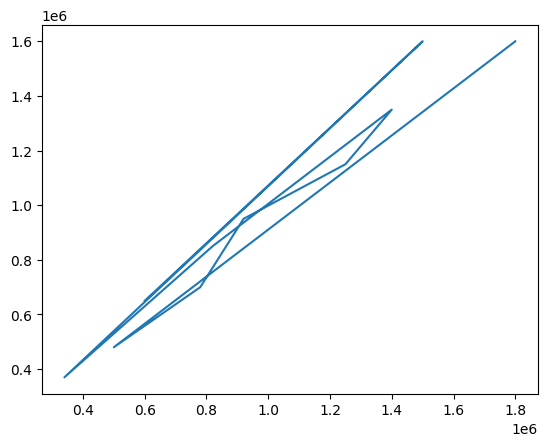

In [18]:
plt.plot(y_test,pre)